Running computational benchmark for N ∈ {100, 500, 1000, 5000, 10000}...


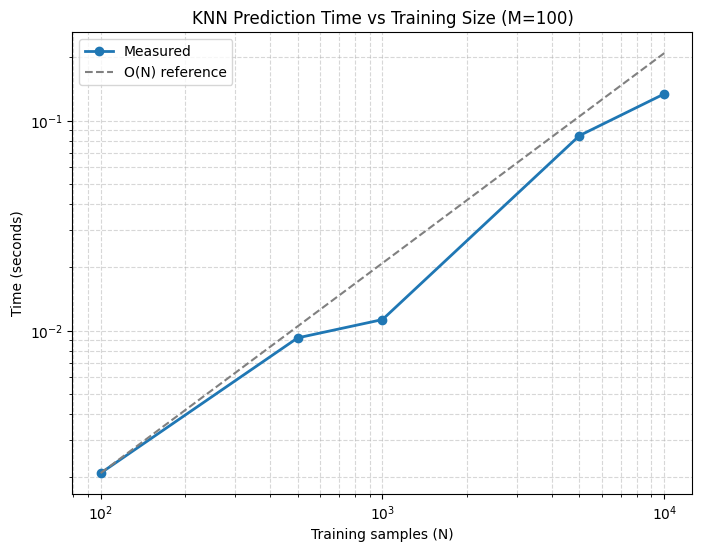

N=  100 -> Time: 0.00209 seconds
N=  500 -> Time: 0.00923 seconds
N= 1000 -> Time: 0.01128 seconds
N= 5000 -> Time: 0.08477 seconds
N=10000 -> Time: 0.13398 seconds


In [1]:
# --- Cell 1: Imports ---
import sys

# Allow Jupyter to find the src module if it's one directory up
sys.path.append('..') 

import numpy as np
import pandas as pd
from src.metrics import accuracy, precision, recall, f1_score, roc_auc
from src.experiments import run_computational_benchmark

# --- Cell 2: Data Preparation ---
# (Replace this with the actual dataframe you cleaned and encoded in Part 1)
# df_clean = pd.read_csv('../data/titanic_cleaned.csv') 
# X = df_clean.drop(columns=['survived']).values
# y = df_clean['survived'].values

# For demonstration, creating synthetic features so the cell runs:
np.random.seed(42)
X = np.random.rand(1500, 10) 
y = np.random.randint(0, 2, 1500)

# We only need X_train, y_train, and X_test for this specific benchmark.
# (If you haven't implemented your stratified_split yet, just do a basic slice for now)
X_train = X[:-200]
y_train = y[:-200]
X_test = X[-200:]

# --- Cell 3: Execute Benchmark ---
# This will execute the loop, draw the log-log plot, and save the PDF to the figures folder
print("Running computational benchmark for N ∈ {100, 500, 1000, 5000, 10000}...")
N_values, times = run_computational_benchmark(X_train, y_train, X_test, k=5, m_test=100)

# Optional: Print raw times for your report write-up
for n, t in zip(N_values, times):
    print(f"N={n:5d} -> Time: {t:.5f} seconds")

In [3]:
import sys
sys.path.append('..')
from src.splits import stratified_split

# Fixed unpacking order (Xs first, then ys) and argument names
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X, y, 
    test_frac=0.15,  # Changed from test_size
    val_frac=0.15,   # Changed from val_size
    seed=42          # Changed from random_state
)

# Sanity check to verify the proportions
print(f"Total positive rate: {y.mean():.4f}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Val positive rate:   {y_val.mean():.4f}")
print(f"Test positive rate:  {y_test.mean():.4f}")

Total positive rate: 0.4900
Train positive rate: 0.4905
Val positive rate:   0.4889
Test positive rate:  0.4889


Running hyperparameter sweep over k...


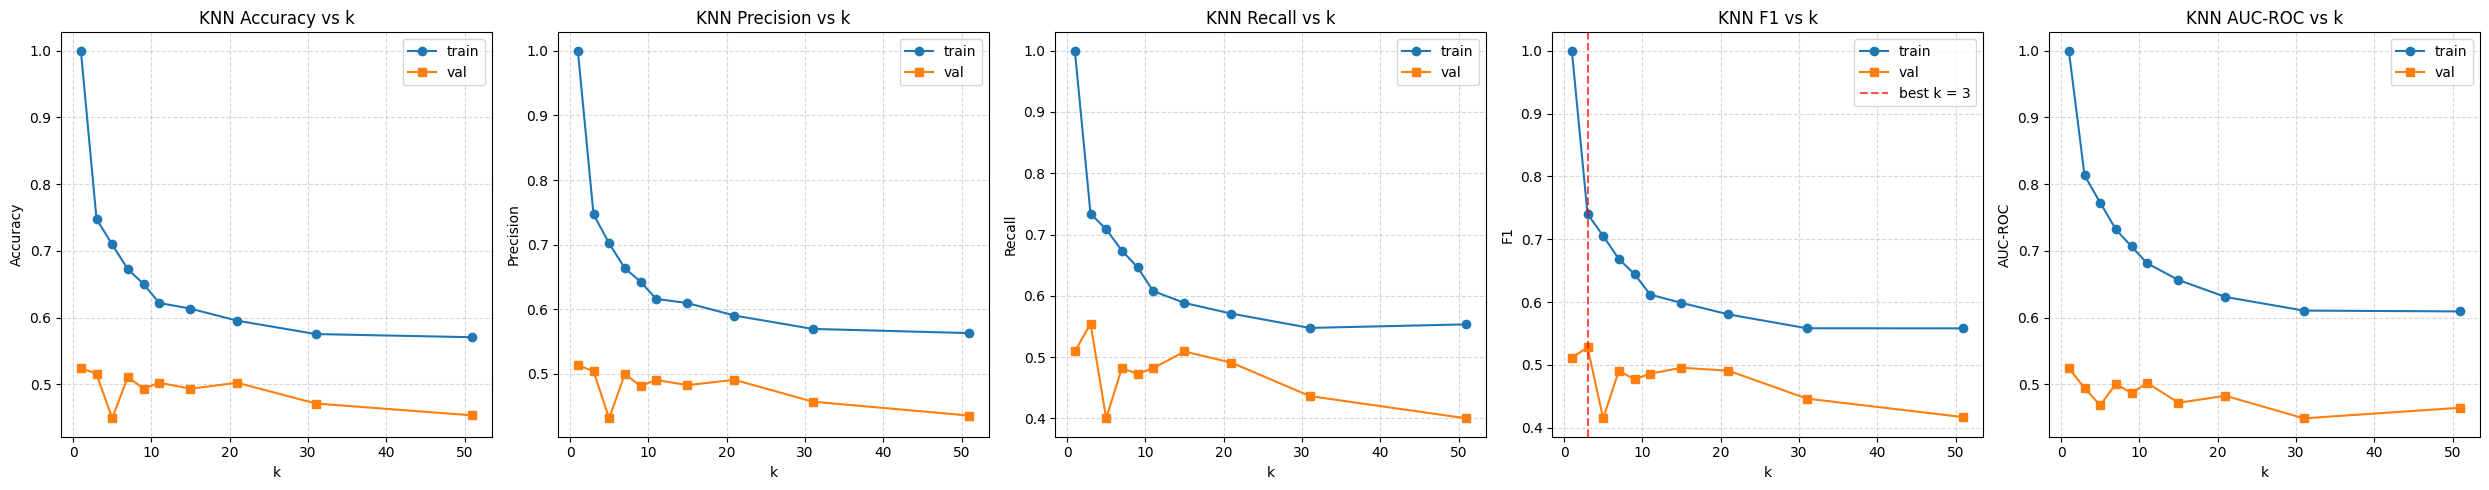


The optimal k selected via Validation F1-score is: k = 3


In [4]:
# --- Cell 4: Run Hyperparameter Sweep ---
import sys
sys.path.append('..')
from src.experiments import run_hyperparameter_sweep

print("Running hyperparameter sweep over k...")
# This uses the X_train, y_train, X_val, y_val from your split in 3.1
best_k = run_hyperparameter_sweep(X_train, y_train, X_val, y_val)

print(f"\nThe optimal k selected via Validation F1-score is: k = {best_k}")

In [5]:
# --- Cell 5: Baseline Comparison ---
import sys
sys.path.append('..')
from src.experiments import evaluate_baselines

print(f"Running baseline comparison with best_k = {best_k}...")

# Run the evaluation
baseline_results = evaluate_baselines(X_train, y_train, X_val, y_val, best_k)

# Display the DataFrame (Jupyter will render this as a nice HTML table)
display(baseline_results)

Running baseline comparison with best_k = 3...


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Custom KNN (k=3),0.515556,0.504132,0.554545,0.528139,0.494308
Sklearn KNN (k=3),0.515556,0.504132,0.554545,0.528139,0.494308
Majority baseline,0.511111,0.000000,0.000000,0.000000,0.500000


In [6]:
# --- Cell 6: Final Test Set Evaluation ---
import sys
sys.path.append('..')
from src.experiments import evaluate_test_set

print(f"Opening the vault: Running final evaluation on test set using best_k = {best_k}...")

# Run the evaluation using the X_test and y_test from your stratified_split in 3.1
test_results = evaluate_test_set(X_train, y_train, X_test, y_test, best_k)

# Display the final scores
display(test_results)

Opening the vault: Running final evaluation on test set using best_k = 3...


,Test Score
Metric,
Accuracy,0.466667
Precision,0.458333
Recall,0.500000
F1 Score,0.478261
AUC-ROC,0.464625


In [7]:
# --- Cell 7: Verify Stratified K-Fold ---
import sys
sys.path.append('..')
from src.splits import stratified_kfold
import numpy as np

# Combine your X_train and X_val from Part 3.1 to create the full development set
X_dev = np.vstack((X_train, X_val))
y_dev = np.concatenate((y_train, y_val))

print(f"Total Dev Set Positive Rate: {y_dev.mean():.4f}\n")

# Generate the 5 folds
folds = stratified_kfold(X_dev, y_dev, n_splits=5, random_state=42)

for i, (X_tr_f, y_tr_f, X_val_f, y_val_f) in enumerate(folds):
    print(f"Fold {i+1}:")
    print(f"  Train positive rate: {y_tr_f.mean():.4f} (Size: {len(y_tr_f)})")
    print(f"  Val positive rate:   {y_val_f.mean():.4f} (Size: {len(y_val_f)})")

Total Dev Set Positive Rate: 0.4902

Fold 1:
  Train positive rate: 0.4902 (Size: 1020)
  Val positive rate:   0.4902 (Size: 255)
Fold 2:
  Train positive rate: 0.4902 (Size: 1020)
  Val positive rate:   0.4902 (Size: 255)
Fold 3:
  Train positive rate: 0.4902 (Size: 1020)
  Val positive rate:   0.4902 (Size: 255)
Fold 4:
  Train positive rate: 0.4902 (Size: 1020)
  Val positive rate:   0.4902 (Size: 255)
Fold 5:
  Train positive rate: 0.4902 (Size: 1020)
  Val positive rate:   0.4902 (Size: 255)


Running 5-fold cross-validation sweep...


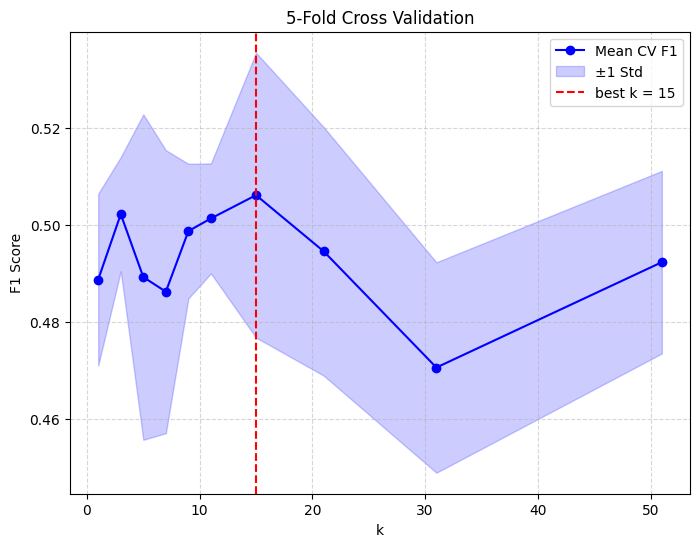


The optimal k selected via 5-Fold Cross-Validation is: k = 15


In [8]:
# --- Cell 8: Run Cross-Validation ---
import sys
sys.path.append('..')
from src.experiments import run_cross_validation_sweep

print("Running 5-fold cross-validation sweep...")
best_cv_k, best_cv_f1 = run_cross_validation_sweep(X_dev, y_dev, n_splits=5)

print(f"\nThe optimal k selected via 5-Fold Cross-Validation is: k = {best_cv_k}")

In [9]:
# --- Cell 9: Scaling Experiment ---
import sys
sys.path.append('..')
from src.experiments import run_scaling_experiment

print(f"Running scaling experiment using CV best_k = {best_cv_k}...")

# Run the scaled CV
scaled_cv_f1 = run_scaling_experiment(X_dev, y_dev, best_cv_k, n_splits=5)

print("-" * 40)
print(f"Unscaled Mean CV F1 Score: {best_cv_f1:.4f}") # from Part 4.2
print(f"Scaled Mean CV F1 Score:   {scaled_cv_f1:.4f}")
print("-" * 40)
diff = scaled_cv_f1 - best_cv_f1
print(f"Net Difference: {diff:+.4f}")

Running scaling experiment using CV best_k = 15...
----------------------------------------
Unscaled Mean CV F1 Score: 0.5062
Scaled Mean CV F1 Score:   0.5018
----------------------------------------
Net Difference: -0.0044
